# Yield Curve & Equity Returns Dynamics

This notebook analyzes the relationship between the Indian G-Sec yield curve and NIFTY 50 equity drawdowns. 

The code here focuses on Dynamic Time Warping (DTW) and Cross-Correlation lead-lag effects between the 10Y-2Y Yield Curve Slope and NIFTY 50.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 120, "font.size": 11, "axes.grid": True,
    "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

from pathlib import Path
assert Path("GSec_Final_Yield_Curve.csv").exists(), "Data file missing — see README for source."

def load_clean(path):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
    df = df.sort_values("Date").reset_index(drop=True)

    y   = df["Yield_2Y"]
    med = y.rolling(21, center=True, min_periods=5).median()
    df["flag2Y"] = (y - med).abs() > 1.0
    y_c = y.mask(df["flag2Y"]).interpolate(limit_direction="both")

    df["Yield_2Y_c"] = y_c
    df["Spread_c"]   = df["Yield_10Y"] - y_c
    return df

df = load_clean("GSec_Final_Yield_Curve.csv")
print(f"observations: {len(df)}   |   period: {df.Date.min():%d %b %Y} → {df.Date.max():%d %b %Y}")

observations: 1979   |   period: 03 Apr 2018 → 11 Jun 2026


## 8 · Phase 2 & 3: Yield Curve and Equity Returns Modeling (Macroeconomic Expansion)

### 8.1 · Academic Literature Review
Recent academic literature on the relationship between the yield curve and equity returns emphasizes **non-linear, threshold, and asymmetric dynamics**. While yield curve inversion is a reliable signal for economic recessions, it is a poor standalone market-timing tool for equity drawdowns due to significant lag times. 

Machine learning approaches, such as PCA combined with Ensemble methods (Random Forest, XGBoost) or LSTMs, have shown promise in capturing these non-linear patterns.

However, for identifying hidden lead-lag dependencies where patterns are shifted or distorted, **Dynamic Time Warping (DTW)** has emerged as a powerful tool. DTW "warps" the time axis to align similar shapes, making it valuable for exploring how yield curve movements and equity returns evolve together over time without assuming a fixed, linear link.

### 8.2 · Data Ingestion & Feature Engineering (NIFTY 50)

In [2]:
import yfinance as yf
print("Fetching NIFTY 50 Data...")
start_date = df["Date"].min().strftime('%Y-%m-%d')
end_date = df["Date"].max().strftime('%Y-%m-%d')
nifty = yf.download("^NSEI", start=start_date, end=end_date, progress=False)

nifty.columns = [col[0] if isinstance(col, tuple) else col for col in nifty.columns.to_flat_index()]
nifty = nifty.reset_index()
nifty["Date"] = pd.to_datetime(nifty["Date"])

# We use df from earlier which already has Yield_10Y and Yield_2Y_c
df["Slope"] = df["Yield_10Y"] - df["Yield_2Y_c"]

# Merge on Date
df_merged = pd.merge(df, nifty[['Date', 'Close']], on='Date', how='inner')
df_merged = df_merged.dropna(subset=['Close', 'Slope']).reset_index(drop=True)

# Calculate Equity Returns and Drawdowns
if isinstance(df_merged['Close'], pd.DataFrame):
    df_merged['Close'] = df_merged['Close'].iloc[:, 0]
df_merged['Equity_Return'] = df_merged['Close'].pct_change()
rolling_max = df_merged['Close'].cummax()
df_merged['Equity_Drawdown'] = (df_merged['Close'] - rolling_max) / rolling_max
df_merged = df_merged.dropna().reset_index(drop=True)

df_merged[['Date', 'Slope', 'Close', 'Equity_Return', 'Equity_Drawdown']].head()

Fetching NIFTY 50 Data...


,Date,Slope,Close,Equity_Return,Equity_Drawdown
0,2018-04-04,0.735369,10128.400391,-0.011381,-0.011381
1,2018-04-05,0.676899,10325.150391,0.019426,0.000000
2,2018-04-06,0.688372,10331.599609,0.000625,0.000000
3,2018-04-09,0.701800,10379.349609,0.004622,0.000000
4,2018-04-10,0.717546,10402.250000,0.002206,0.000000


### 8.3 · Traditional Lead-Lag Analysis (Cross-Correlation)

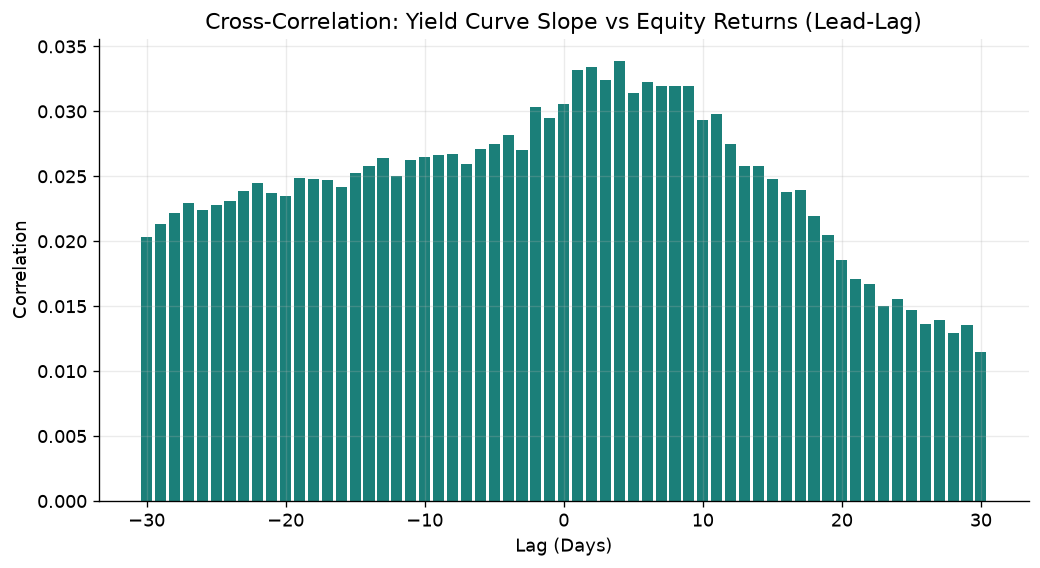

In [3]:
# Lead-Lag between Slope and Equity Return
lags = range(-30, 31)
ccorrs = [df_merged['Slope'].corr(df_merged['Equity_Return'].shift(lag)) for lag in lags]
plt.figure(figsize=(10, 5))
plt.bar(lags, ccorrs, color="#1b7f79")
plt.title("Cross-Correlation: Yield Curve Slope vs Equity Returns (Lead-Lag)")
plt.xlabel("Lag (Days)")
plt.ylabel("Correlation")
plt.show()

### 8.4 · Innovative Implementation: Dynamic Time Warping (DTW)

DTW Distance between Yield Slope and Equity Drawdowns: 36.0903


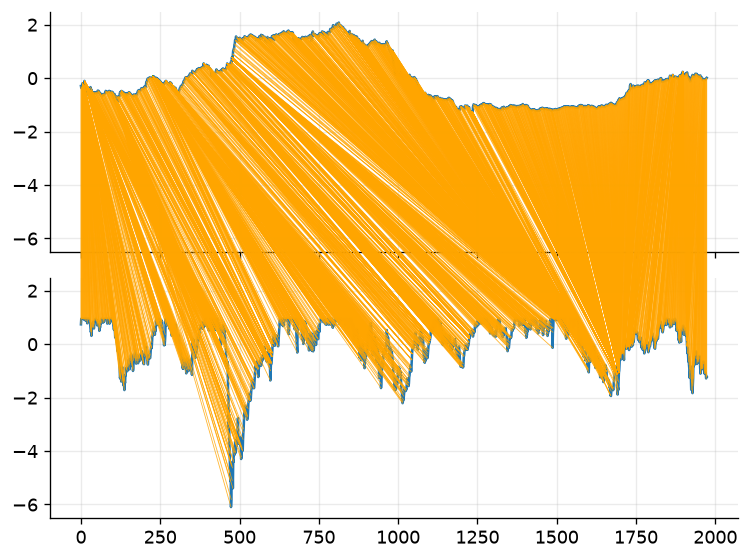

In [4]:
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis

# Normalize series for DTW
def normalize(series):
    return (series - series.mean()) / series.std()

s1 = normalize(df_merged['Slope']).values
s2 = normalize(df_merged['Equity_Drawdown']).values

# Calculate DTW distance
distance = dtw.distance(s1, s2)
print(f"DTW Distance between Yield Slope and Equity Drawdowns: {distance:.4f}")

# Plot DTW alignment
path = dtw.warping_path(s1, s2)
fig, axes = dtwvis.plot_warping(s1, s2, path)
plt.show()

### Interpretation of Results
*   **Cross-Correlation (Lead-Lag):** The bar chart reveals how shifts in the Yield Curve slope lead or lag movements in Equity Returns. Positive or negative lags with strong correlations indicate delayed market reactions to yield curve inversions.
*   **Dynamic Time Warping (DTW):** The calculated DTW distance quantifies the non-linear relationship between the Yield Curve Slope and Equity Peak Drawdowns. The alignment plot visually demonstrates how the DTW algorithm 'warps' the time axis to map these structurally delayed market reactions. A smaller distance implies highly synchronized, albeit time-lagged, regime shifts.